# Sheet 9 — Training a neural network (Solutions)

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import shutil

fontsi, fontsi2 = 15, 20                      
if shutil.which('latex') is not None:      
    plt.rc('text', usetex=True)
    plt.rcParams['font.serif'] = ['Computer Modern']
plt.rc('font', family='serif')
plt.rcParams.update({
    'font.size': fontsi, 'axes.titlesize': fontsi, 'axes.labelsize': fontsi2,
    'xtick.labelsize': fontsi, 'ytick.labelsize': fontsi,
    'axes.spines.top': True, 'axes.spines.right': True,   # drop the top/right box lines
    'axes.grid': False, 'legend.frameon': False, 'figure.dpi': 130,
     "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 5,
    "ytick.major.size": 5,
    "xtick.top": True,
    "ytick.right": True,
})
cols = ["black", "red", "blue", "green", "cyan", "purple", "brown", "pink", "gray", "olive"]

# each row is (x, y); column 0 is the input, column 1 the noisy target
train = np.loadtxt('./data/sheet_9_data.txt')  # 200 training points
test  = np.loadtxt('./data/sheet_9_test.txt')  # 2000 held-out test points
X,  y  = train[:, :1], train[:, 1:2]           # keep as (N,1) column vectors, not (N,)
Xt, yt = test[:, :1],  test[:, 1:2]

# standardise the inputs to zero mean / unit variance 
# NNs train much better on O(1) inputs; we fit mu/sd on the TRAIN set only
# and reuse them on the test set (never peek at test statistics).
x_mu, x_sd = X.mean(0), X.std(0)
Xs  = (X  - x_mu) / x_sd                        # standardised training inputs
Xts = (Xt - x_mu) / x_sd                        # standardised test inputs (same transform)

# true data-generating process (known here only for evaluation)
def target(x):
    return np.sin(2*np.pi*x)      # h*(x) = <y|x>, the best possible predictor
noise = 0.10                      # sigma of the additive noise; irreducible sigma^2 = 0.01

print(f"{X.shape[0]} training points,  {Xt.shape[0]} test points,  "
      f"sigma^2 = {noise**2:.4f}")

200 training points,  2000 test points,  sigma^2 = 0.0100


## 9a Network, backpropagation, and gradient check

We initialise with small random weights (zero would make all hidden units identical and receive identical gradients, a symmetry that never breaks). The forward pass caches the hidden pre-activation $\boldsymbol{z}$ and activation $\boldsymbol{h}$; backprop implements Eqs. 7.32–7.34 with $a'(z)=1-\tanh^2 z$. The finite-difference check agrees to machine precision, confirming the gradients.

In [158]:
# 9a  network, backprop, and gradient check
# One hidden layer:  x -> [W1,b1] -> tanh -> [W2,b2] -> yhat
def init_params(H, seed=0):
    r = np.random.default_rng(seed)
    return {                                      # small RANDOM weights break the
        "W1": r.normal(0, 0.5, (H, 1)), "b1": np.zeros((H, 1)),   # input->hidden weights
        "W2": r.normal(0, 0.5, (1, H)), "b2": np.zeros((1, 1)),   # hidden->output weights
    }                                             # (zeros would make all H units identical)


H = 32                                            # hidden-layer width

def forward(p, X):
    """X: (N,1). Returns prediction (N,1) and the hidden pre-/post-activations."""
    Z  = p["W1"] @ X.T + p["b1"]       # (H, N) pre-activation z = W1 x + b1 for every point
    Hh = np.tanh(Z)                    # (H, N) hidden activation h = tanh(z)
    yhat = (p["W2"] @ Hh + p["b2"]).T  # (N, 1) linear read-out of the hidden units
    return yhat, Z, Hh                 # cache Z, Hh -- backprop needs them

def loss_and_grad(p, X, y):
    N = X.shape[0]
    yhat, Z, Hh = forward(p, X)        # forward pass (and cache)
    r = yhat - y                       # (N, 1) residual = prediction - target
    mse = np.mean(r**2)                # loss  R = (1/N) sum r^2
    # backprop: chain-rule gradients of the MSE (Eqs. 7.32-7.34)
    # d R / d yhat = (2/N) r ; propagate it back through each layer:
    gW2 = (2/N) * (r.T @ Hh.T)                       # (1, H) output weights: r * hidden acts
    gb2 = (2/N) * np.sum(r, axis=0, keepdims=True)   # (1, 1) output bias: sum of residuals
    delta = (p["W2"].T @ r.T) * (1 - np.tanh(Z)**2)  # (H, N) error at hidden units x tanh'(z)
    gW1 = (2/N) * (delta @ X)                        # (H, 1) input weights: delta * inputs
    gb1 = (2/N) * np.sum(delta, axis=1, keepdims=True)  # (H, 1) input bias: sum of delta
    return mse, {"W1": gW1, "b1": gb1, "W2": gW2, "b2": gb2}

def mse_of(p, X, y):                   # convenience: loss only, no gradient
    return np.mean((forward(p, X)[0] - y)**2)

# finite-difference check: does the analytic gradient match d R / d theta?
p = init_params(H, seed=3)
_, g = loss_and_grad(p, Xs, y)         # analytic gradient at this theta
eps, max_err = 1e-6, 0.0
rng = np.random.default_rng(0)
for _ in range(20):                    # test 20 randomly chosen parameters
    k = rng.choice(["W1", "b1", "W2", "b2"])         # pick a weight array...
    i = rng.integers(p[k].shape[0]); j = rng.integers(p[k].shape[1])   # ...and an entry
    p[k][i, j] += eps; Lp = mse_of(p, Xs, y)         # loss at theta + eps
    p[k][i, j] -= 2*eps; Lm = mse_of(p, Xs, y)       # loss at theta - eps
    p[k][i, j] += eps                                # restore theta
    # central difference (Lp - Lm)/(2 eps) approximates the true derivative
    max_err = max(max_err, abs((Lp - Lm)/(2*eps) - g[k][i, j]))
print(f"max |analytic - finite difference| over 20 parameters: {max_err:.2e}")

max |analytic - finite difference| over 20 parameters: 2.34e-10


## 9b Full-batch gradient descent

The loss decreases smoothly for a well-chosen step. Too small a learning rate ($\eta_0=0.01$) converges very slowly; a good rate ($\eta_0=0.1$–$0.2$) is fast and smooth; too large ($\eta_0=0.5$) overshoots the minimum and the loss diverges.

The two good curves ($\eta_0=0.1,\,0.2$) show sharp, narrow spikes where the loss jumps up by an order of magnitude for a couple of iterations and then drops right back onto the descent curve. These are *not* noise — full-batch GD uses the exact gradient and is fully deterministic, so the spikes recur at the same iterations on every run. They are the edge of stability effect: the stability bound $\eta<2/\lambda_{\max}$ depends on the local curvature $\lambda_{\max}$, which changes as the weights move. A well-tuned GD does not sit safely below the bound but hovers right at it, so as the iterate drifts into a sharper region ($\lambda_{\max}$ momentarily exceeds $2/\eta$) a single step overshoots and the loss jumps — but that same overshoot kicks it into a flatter region where $\eta$ is safe again, so descent immediately resumes. The larger rate ($\eta_0=0.2$) grazes the edge more often than $\eta_0=0.1$, while the tiny $\eta_0=0.01$ stays far below the bound and never spikes. `tanh` units aggravate this because saturating hidden units shift the effective curvature. The transients are self-correcting and all well-tuned rates settle near the same loss; adaptive optimisers like Adam smooth them away by rescaling each update by the gradient's magnitude.

Here $\lambda_{\max}$ is the largest eigenvalue of the Hessian $\nabla^2\hat R$ — the matrix of second derivatives of the loss with respect to the weights. It measures the curvature of the loss surface in its *steepest* direction: along that direction the loss looks locally like a parabola $\tfrac12\lambda_{\max}\,\Delta\theta^2$, so a large $\lambda_{\max}$ means a narrow, sharply curved valley. Gradient descent on a quadratic with curvature $\lambda$ multiplies the distance to the minimum by $(1-\eta\lambda)$ each step, which only shrinks when $\eta<2/\lambda$; applied to the steepest direction this gives the stability bound $\eta<2/\lambda_{\max}$. Step past it and that direction is amplified rather than damped.

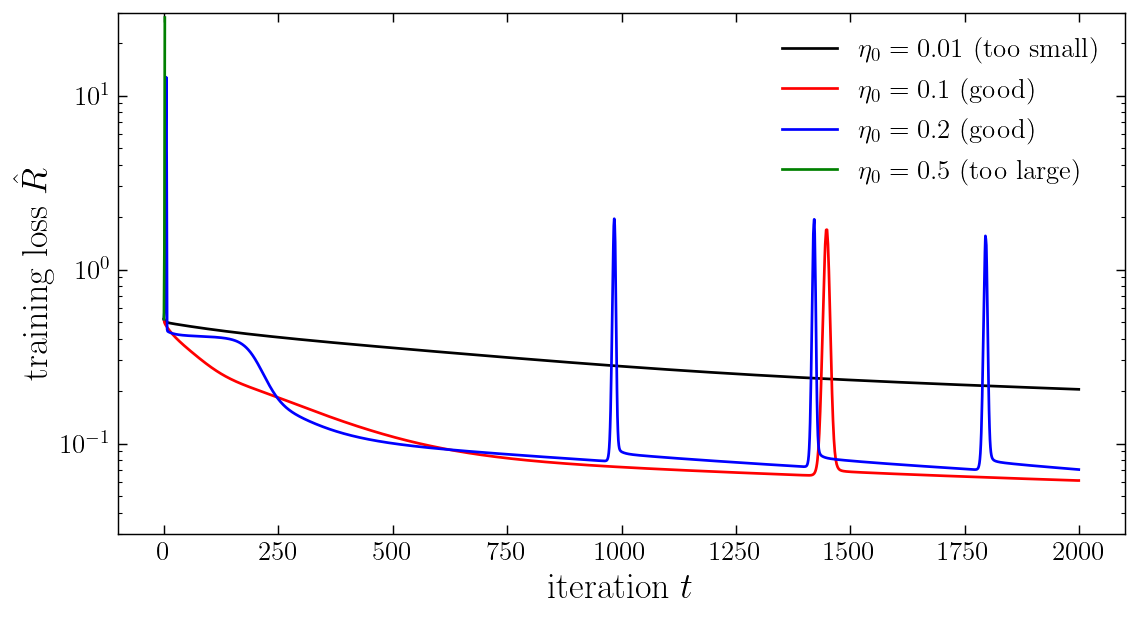

In [159]:
# ---- 9b  full-batch gradient descent (Eq. 7.26) -------------------------
def train_gd(p, X, y, lr, epochs):
    hist = np.empty(epochs)                              # loss recorded at every step
    with np.errstate(over='ignore', invalid='ignore'):  # a too-large lr may overflow to inf/nan
        for t in range(epochs):
            loss, g = loss_and_grad(p, X, y)            # full-batch: gradient uses ALL points
            hist[t] = loss                              # store loss BEFORE the update
            for k in p:                                 # gradient step on every parameter array
                p[k] -= lr * g[k]                       # theta <- theta - eta * grad
    return hist

fig, ax = plt.subplots(figsize=(9, 5))
labels = {0.01: r"$\eta_0=0.01$ (too small)", 0.1: r"$\eta_0=0.1$ (good)",
          0.2: r"$\eta_0=0.2$ (good)", 0.5: r"$\eta_0=0.5$ (too large)"}
for base, c in zip([0.01, 0.1, 0.2, 0.5], cols):        # one curve per base learning rate
    # fresh identical init each time (same seed) so only the learning rate differs
    h = train_gd(init_params(H, seed=7), Xs, y, base, epochs=2000)
    h = np.where(h < 30, h, np.nan)         # hide the diverging tail above the y-limit
    ax.plot(h, color=c, label=labels[base])
ax.set_yscale('log')                        # loss spans decades -> log axis
ax.set_ylim(3e-2, 30)                       # the diverging curve shoots off the top
ax.set_xlabel("iteration $t$", fontsize=fontsi2)
ax.set_ylabel(r"training loss $\hat R$", fontsize=fontsi2)
ax.legend(fontsize=fontsi)
plt.tight_layout(); plt.savefig("sheet9_output/sheet9_learningrate.pdf", bbox_inches="tight"); plt.show()

**Left:** gradient descent moves by $-\eta\nabla\hat R$, a step whose *length* is fixed by $\eta$ but whose *usefulness* depends on the local curvature $\lambda_{\max}$. In a wide valley (small $\lambda$) the step lands lower — smooth descent. In a narrow valley (large $\lambda$) the *same* step overshoots the minimum and lands higher up the opposite wall, so the loss jumps up. **Right:** on a locally quadratic loss one step multiplies the distance to the minimum by $(1-\eta\lambda)$, hence the loss by $(1-\eta\lambda)^2$ — which is below $1$ (contraction, smooth descent) only while $\lambda<2/\eta$. During a calm descent the network's sharpness $\lambda_{\max}$ tends to *drift upward* (progressive sharpening); once it crosses $2/\eta$ a single step is amplified — a spike — and that same overshoot kicks the iterate into a flatter region where $\lambda_{\max}$ drops back below the line, so descent resumes. That self-correcting loop is exactly the intermittent spike-and-recover seen on the $\eta_0=0.1,0.2$ curves above.

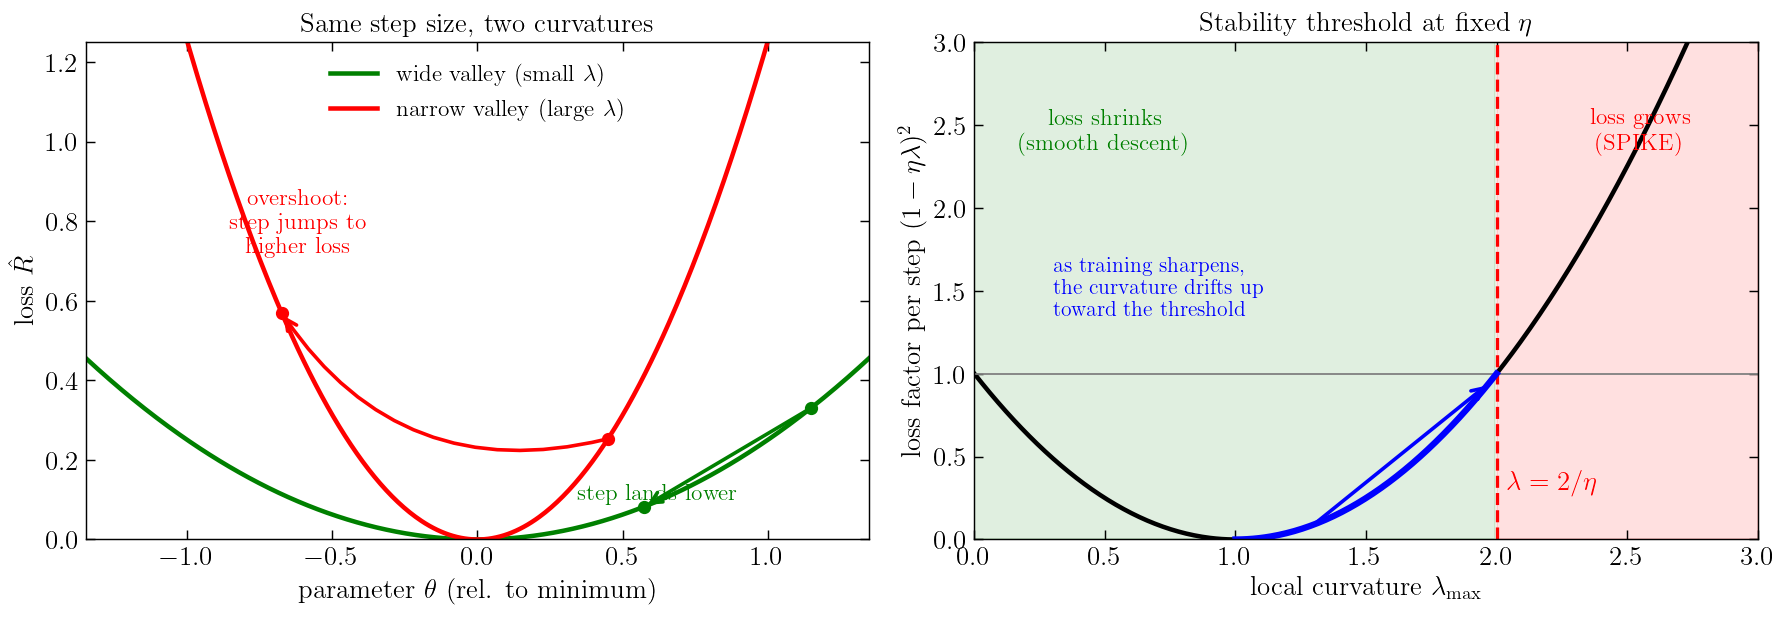

In [160]:
# 9b (extra)  intuition for the spikes: overshoot at the edge of stability
eta_ill = 1.0
lam_w, lam_n = 0.5, 2.5                      # wide (gentle) vs narrow (sharp) valley
th = np.linspace(-1.35, 1.35, 400)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

# -- Panel A: one GD step in a wide vs a narrow valley (same eta) --
axA.plot(th, 0.5*lam_w*th**2, color=cols[3], lw=2.5, label=r"wide valley (small $\lambda$)")
axA.plot(th, 0.5*lam_n*th**2, color=cols[1], lw=2.5, label=r"narrow valley (large $\lambda$)")
t0 = 1.15; t1 = (1 - eta_ill*lam_w)*t0        # wide: step lands lower (contraction)
axA.annotate("", xy=(t1, 0.5*lam_w*t1**2), xytext=(t0, 0.5*lam_w*t0**2),
             arrowprops=dict(arrowstyle="->", color=cols[3], lw=2))
axA.scatter([t0, t1], [0.5*lam_w*t0**2, 0.5*lam_w*t1**2], color=cols[3], s=40, zorder=5)
s0 = 0.45; s1 = (1 - eta_ill*lam_n)*s0        # narrow: step overshoots to higher loss
axA.annotate("", xy=(s1, 0.5*lam_n*s1**2), xytext=(s0, 0.5*lam_n*s0**2),
             arrowprops=dict(arrowstyle="->", color=cols[1], lw=2, connectionstyle="arc3,rad=-0.35"))
axA.scatter([s0, s1], [0.5*lam_n*s0**2, 0.5*lam_n*s1**2], color=cols[1], s=40, zorder=5)
axA.text(-0.62, 0.72, "overshoot:\nstep jumps to\nhigher loss", color=cols[1], ha="center", fontsize=13)
axA.text(0.62, 0.10, "step lands lower", color=cols[3], ha="center", fontsize=13)
axA.set_ylim(0, 1.25); axA.set_xlim(-1.35, 1.35)
axA.set_xlabel(r"parameter $\theta$ (rel. to minimum)", fontsize=fontsi)
axA.set_ylabel(r"loss $\hat R$", fontsize=fontsi)
axA.legend(loc="upper center", fontsize=13)
axA.set_title("Same step size, two curvatures", fontsize=fontsi)

# -- Panel B: per-step loss amplification factor and the stability threshold --
lam = np.linspace(0, 3.0, 400); rho = (1 - eta_ill*lam)**2
axB.fill_between(lam, 0, 3, where=lam < 2/eta_ill, color=cols[3], alpha=0.12)
axB.fill_between(lam, 0, 3, where=lam >= 2/eta_ill, color=cols[1], alpha=0.12)
axB.plot(lam, rho, color=cols[0], lw=2.5)
axB.axhline(1, color=cols[8], lw=1)
axB.axvline(2/eta_ill, color=cols[1], ls="--", lw=1.8)
seg = (lam >= 1.0) & (lam <= 2.0)             # highlight the "sharpening" drift toward the edge
axB.plot(lam[seg], rho[seg], color=cols[2], lw=3.5)
axB.annotate("", xy=(1.97, rho[np.argmin(abs(lam-1.97))]), xytext=(1.3, rho[np.argmin(abs(lam-1.3))]),
             arrowprops=dict(arrowstyle="->", color=cols[2], lw=2))
axB.text(0.5, 2.35, "loss shrinks\n(smooth descent)", color=cols[3], ha="center", fontsize=13)
axB.text(2.55, 2.35, "loss grows\n(SPIKE)", color=cols[1], ha="center", fontsize=13)
axB.text(0.30, 1.35, "as training sharpens,\nthe curvature drifts up\ntoward the threshold", color=cols[2], fontsize=12)
axB.text(2.04, 0.30, r"$\lambda=2/\eta$", color=cols[1], fontsize=15, ha="left")
axB.set_ylim(0, 3); axB.set_xlim(0, 3)
axB.set_xlabel(r"local curvature $\lambda_{\max}$", fontsize=fontsi)
axB.set_ylabel(r"loss factor per step $(1-\eta\lambda)^2$", fontsize=fontsi)
axB.set_title(r"Stability threshold at fixed $\eta$", fontsize=fontsi)

plt.tight_layout(); plt.savefig("sheet9_output/sheet9_spikes_intuition.pdf", bbox_inches="tight"); plt.show()

The main figure clips the $\eta_0=0.5$ curve above its $y$-limit, so it only shows up as a stub. Here we plot that run alone and unclipped. Because $\eta$ exceeds the stability bound $2/\lambda_{\max}$ from the very first step, every update overshoots onto a still-steeper part of the loss, so the loss grows by a roughly *constant factor per iteration* — a straight line on a log axis (here $\approx 2.5$ decades/step). 

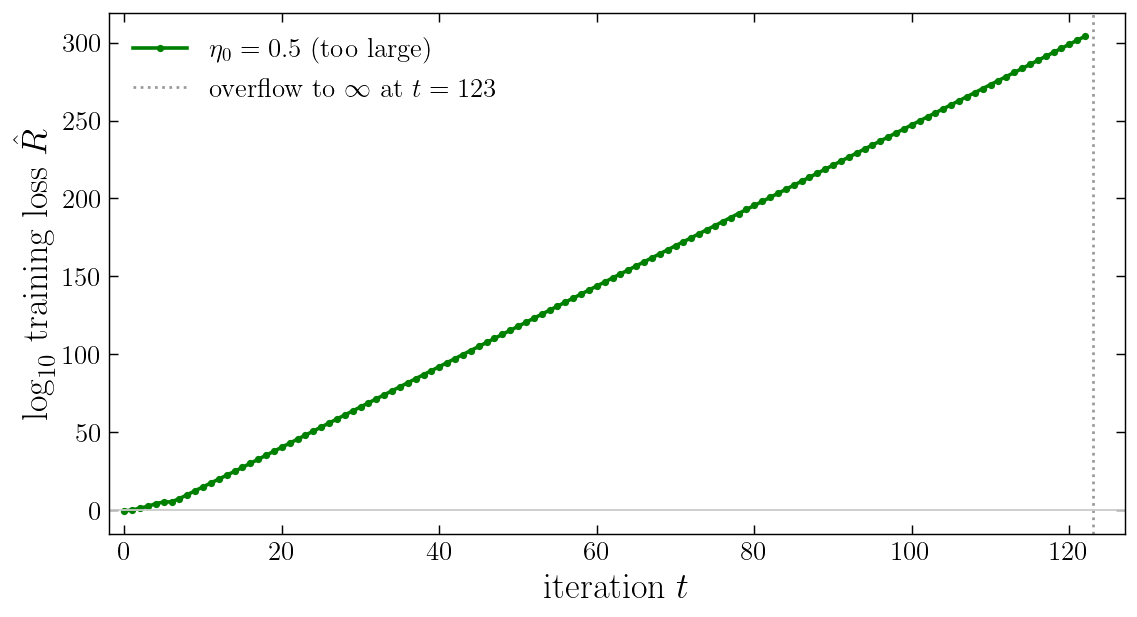

In [161]:
# reuses train_gd / init_params from the cell above
h = train_gd(init_params(H, seed=7), Xs, y, 0.5, epochs=2000)
finite = np.isfinite(h)
n_blow = int(np.argmax(~finite)) if (~finite).any() else len(h)   # first inf/nan
t = np.arange(len(h))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(t[finite], np.log10(h[finite]), color=cols[3], lw=2, marker='o', ms=3,
        label=r"$\eta_0=0.5$ (too large)")
ax.axvline(n_blow, color="0.6", ls=":", label=rf"overflow to $\infty$ at $t={n_blow}$")
ax.axhline(0, color="0.8", lw=1)
ax.set_xlim(-2, n_blow + 4)
ax.set_xlabel("iteration $t$", fontsize=fontsi2)
ax.set_ylabel(r"$\log_{10}$ training loss $\hat R$", fontsize=fontsi2)
ax.legend(fontsize=fontsi)
plt.tight_layout()
plt.savefig("sheet9_output/sheet9_diverge.pdf", bbox_inches="tight"); plt.show()


## 9c Mini-batch SGD

SGD (Eq. 7.30) makes many cheap, noisy updates per epoch. Its loss curve is jagged because each mini-batch gradient is only an unbiased estimate of the full gradient, but it reaches a low loss in far fewer passes over the data — each epoch costs about the same as a single full-batch step yet performs $N/|\mathcal{B}|$ updates. We track both the training and the held-out test MSE: for this well-matched network the two curves stay close (so there is no meaningful overfitting), and both *descend toward* the irreducible $\sigma^2$, though within this short 400-epoch budget neither actually reaches it (see 9d). SGD nonetheless gets substantially lower than full-batch GD at the same budget.

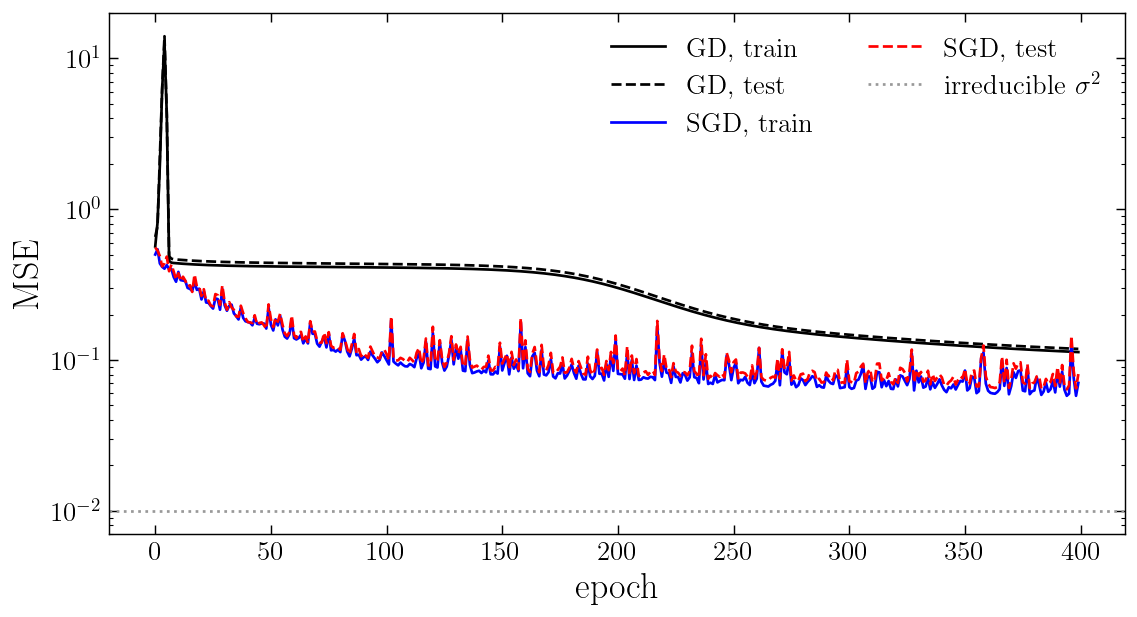

GD :  train MSE = 0.1128,  test MSE = 0.1184
SGD:  train MSE = 0.0705,  test MSE = 0.0806   (sigma^2 = 0.0100)


In [162]:
# each optimiser records the TRAIN and the held-out TEST MSE once per epoch
def train_sgd(p, X, y, lr, epochs, batch=16, seed=0):
    r = np.random.default_rng(seed); N = X.shape[0]; tr, te = [], []
    for ep in range(epochs):
        idx = r.permutation(N)                  # reshuffle the data order every epoch
        for s in range(0, N, batch):            # sweep the data in mini-batches
            bi = idx[s:s+batch]                 # indices of this mini-batch
            _, g = loss_and_grad(p, X[bi], y[bi])   # gradient from the batch ONLY (noisy estimate)
            for k in p:
                p[k] -= lr * g[k]               # many small updates per epoch (N/batch of them)
        tr.append(mse_of(p, X, y)); te.append(mse_of(p, Xts, yt))   # log full train & test MSE
    return np.array(tr), np.array(te)

def train_gd_track(p, X, y, lr, epochs):
    # same as train_gd but logs train AND test MSE per step for the comparison plot
    tr, te = [], []
    for t in range(epochs):
        _, g = loss_and_grad(p, X, y)           # full-batch gradient (exact)
        for k in p:
            p[k] -= lr * g[k]
        tr.append(mse_of(p, X, y)); te.append(mse_of(p, Xts, yt))
    return np.array(tr), np.array(te)

epochs = 400
# start BOTH optimisers from the identical initial weights so the comparison is fair
p_gd, p_sgd = init_params(H, seed=7), init_params(H, seed=7)
gd_tr,  gd_te  = train_gd_track(p_gd,  Xs, y, lr=0.2,  epochs=epochs)
sgd_tr, sgd_te = train_sgd     (p_sgd, Xs, y, lr=0.05, epochs=epochs, batch=16, seed=1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(gd_tr,  color=cols[0], label=r"GD, train")           # solid = train
ax.plot(gd_te,  color=cols[0], ls="--", label=r"GD, test")   # dashed = held-out test
ax.plot(sgd_tr, color=cols[2], label=r"SGD, train")
ax.plot(sgd_te, color=cols[1], ls="--", label=r"SGD, test")
ax.axhline(noise**2, color="0.6", ls=":", label=r"irreducible $\sigma^2$")  # best possible MSE
ax.set_yscale('log')
ax.set_xlabel("epoch", fontsize=fontsi2)
ax.set_ylabel(r"MSE", fontsize=fontsi2)
ax.legend(fontsize=fontsi, ncol=2)
plt.tight_layout()
plt.savefig("sheet9_output/sheet9_gd_vs_sgd.pdf", bbox_inches="tight"); plt.show()
print(f"GD :  train MSE = {gd_tr[-1]:.4f},  test MSE = {gd_te[-1]:.4f}")
print(f"SGD:  train MSE = {sgd_tr[-1]:.4f},  test MSE = {sgd_te[-1]:.4f}   (sigma^2 = {noise**2:.4f})")

## 9d The learned function

The network reproduces the *shape* of $h^\star(x)=\sin(2\pi x)$, but only roughly: the curve is visibly flattened and lags the true sine, and the **test** MSE ($\approx 0.08$) sits *well above* the irreducible noise $\sigma^2=0.01$ (RMS deviation from $h^\star$ of $\approx 0.26$, about a quarter of the sine's amplitude).

Why isn't it better? This is under-training, not a fundamental limit. The tell-tale sign is that the training MSE ($\approx 0.07$) is itself far above $\sigma^2$: the network has not even fit its 200 training points yet, so the poor fit is estimation/optimisation error — not overfitting (the train/test gap is small) and not the irreducible-noise floor. Nor is it a capacity problem: $H=32$ `tanh` units easily represent two periods of a sine. The cause is simply the optimiser budget — 400 epochs of plain, constant-rate SGD leaves the loss still descending. Training the same network longer bears this out: $\sim\!2000$ epochs reach test MSE $\approx 0.03$, and $\sim\!8000$ epochs reach $\approx 0.015$ with RMS$(h_\theta-h^\star)\approx 0.07$ — the fit converges onto $h^\star$ as the budget grows, and the train/test gap stays small throughout. In practice the efficient fix is a better optimiser (adaptive step size + momentum) rather than merely more plain-SGD steps — which is exactly what the PyTorch cell at the end demonstrates: Adam recovers $h^\star$ down to the noise floor in a fraction of the effort.

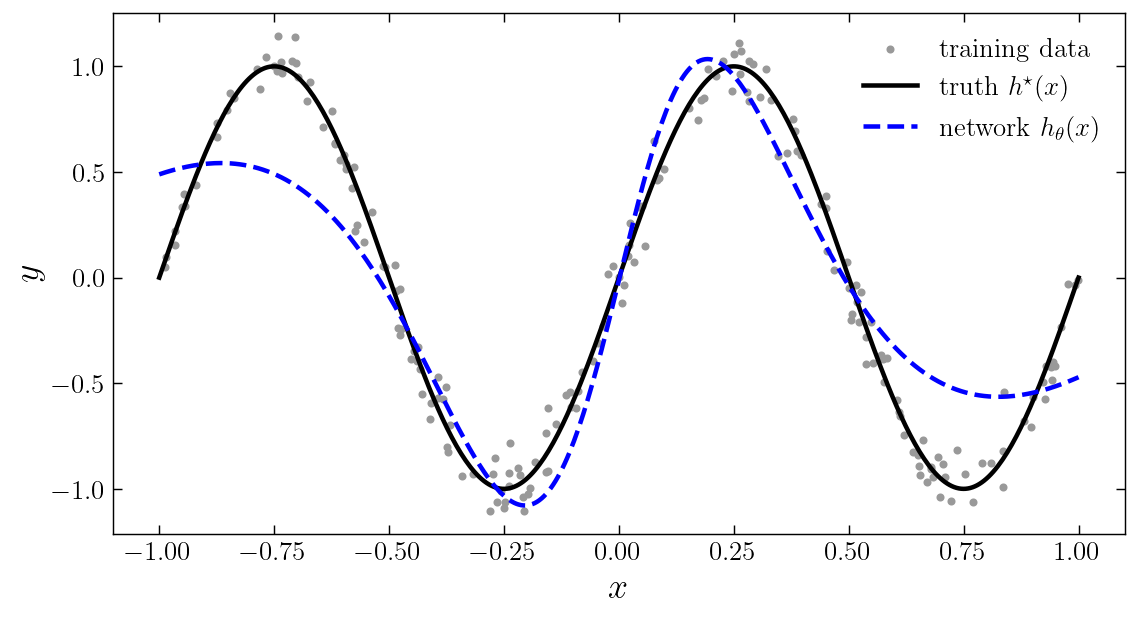

In [163]:
xg = np.linspace(-1, 1, 400)[:, None]          # a dense grid of inputs, shape (400,1)
# feed the grid through the SGD-trained net; standardise with the SAME train mu/sd
yg = forward(p_sgd, (xg - x_mu)/x_sd)[0]        # [0] = predictions (drop cached activations)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X, y, s=12, color="0.6", label="training data", zorder=1)          # noisy samples
ax.plot(xg, target(xg), color=cols[0], lw=2.5, label=r"truth $h^\star(x)$")   # true sine
ax.plot(xg, yg, color=cols[2], lw=2.5, ls="--", label=r"network $h_\theta(x)$")  # learned fit
ax.set_xlabel("$x$", fontsize=fontsi2); ax.set_ylabel("$y$", fontsize=fontsi2)
ax.legend(fontsize=fontsi)
# report train vs test MSE in the title; compare against the irreducible sigma^2 floor
plt.tight_layout(); plt.savefig("sheet9_output/sheet9_fit.pdf", bbox_inches="tight"); plt.show()

## The same network in a few lines of PyTorch

Everything above — the forward pass, the hand-derived backprop of Eqs. 7.32–7.34, and the SGD loop — is what a framework does for you automatically. Below we build the *identical* architecture (one hidden layer of $H=32$ `tanh` units) in PyTorch: `nn.Sequential` defines the model, `loss.backward()` replaces our analytic gradients with reverse-mode autodiff, and `Adam` supplies the adaptive, momentum-based step we motivated in 9b/9d. With that optimiser the network converges onto $h^\star$ down to the irreducible $\sigma^2=0.01$.

In [ ]:
# ---- the same network in a few lines of PyTorch (autograd + Adam) --------
import torch, torch.nn as nn

def to_std(a):                                   # reuse the notebook's standardisation
    return torch.tensor((a - x_mu) / x_sd, dtype=torch.float32)   # numpy -> float32 tensor
Xs_t,  y_t  = to_std(X),  torch.tensor(y,  dtype=torch.float32)   # train inputs / targets
Xts_t, yt_t = to_std(Xt), torch.tensor(yt, dtype=torch.float32)   # test  inputs / targets

H = 32
torch.manual_seed(0)                                              # reproducible init
net = nn.Sequential(nn.Linear(1, H), nn.Tanh(), nn.Linear(H, 1))  # identical architecture
opt = torch.optim.Adam(net.parameters(), lr=1e-2)                 # adaptive optimiser
loss_fn = nn.MSELoss()                                            # same MSE objective

for epoch in range(3000):                        # full-batch training loop
    opt.zero_grad()                              # clear gradients from the previous step
    loss_fn(net(Xs_t), y_t).backward()           # forward + autodiff backprop (no hand math!)
    opt.step()                                   # Adam parameter update

with torch.no_grad():                            # evaluation: no gradient tracking needed
    tr = loss_fn(net(Xs_t),  y_t ).item()        # final train MSE
    te = loss_fn(net(Xts_t), yt_t).item()        # final test  MSE
    xg = np.linspace(-1, 1, 400)[:, None]        # dense grid for the curve
    yg_t = net(to_std(xg)).numpy()               # network prediction on the grid

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X, y, s=12, color="0.6", label="training data", zorder=1)
ax.plot(xg, target(xg), color=cols[0], lw=2.5, label=r"truth $h^\star(x)$")
ax.plot(xg, yg_t, color=cols[3], lw=2.5, ls="--", label=r"PyTorch net $h_\theta(x)$")
ax.set_xlabel("$x$", fontsize=fontsi2); ax.set_ylabel("$y$", fontsize=fontsi2)
ax.legend(fontsize=fontsi)
plt.tight_layout()
plt.savefig("sheet9_output/sheet9_pytorch.pdf", bbox_inches="tight"); plt.show()
print(f"PyTorch:  train MSE = {tr:.4f},  test MSE = {te:.4f}   (sigma^2 = {noise**2:.4f})")